# Multi-Agent WMS Optimization (Floors 1-4 Only)

This notebook implements a detailed multi-agent optimization system for **incoming storage mode** on floors **1, 2, 3, 4** only.

Ground-floor (`0` / RDC) locations are explicitly excluded.

Implemented agents:
1. Storage Optimization Agent (weighted multi-criteria)
2. Demand Frequency Agent (ABC + exponential smoothing)
3. Slot Availability Agent (matrix + constraints)
4. Collision Avoidance Agent (reservation table)
5. Chariot Capacity Agent (greedy knapsack)
6. Coordinator Agent (orchestration pipeline)

Data source: `ai/Data/*.xlsx`

## 1) Imports and Data Loading
This section initializes the technical foundation of the simulation pipeline.

- Loads warehouse reference tables from `ai/Data/*.xlsx` with robust path resolution.
- Parses floor identifiers and keeps only floors **1–4** (RDC excluded by design).
- Builds deterministic `(x, y)` slot coordinates per floor for scoring and routing.
- Normalizes zone/type fields to make rule-based filtering stable.

Why it matters: every downstream optimization depends on consistent slot geometry and clean identifiers.

In [14]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from heapq import heappush, heappop
import math
import re

import numpy as np
import pandas as pd

def resolve_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "ai" / "Data",
        cwd.parent / "Data",
        cwd / "Data",
    ]

    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / "ai" / "Data")
        candidates.append(parent / "Data")

    for candidate in candidates:
        if candidate.exists() and any(candidate.glob("*.xlsx")):
            return candidate

    raise FileNotFoundError(
        "Could not resolve ai/Data with .xlsx files. "
        "Open notebook from repo root or ensure data files exist in ai/Data."
    )

DATA_DIR = resolve_data_dir()

def find_data_file(keyword: str) -> Path:
    matches = [p for p in DATA_DIR.glob("*.xlsx") if keyword.lower() in p.name.lower()]
    if not matches:
        raise FileNotFoundError(f"Missing data file containing: {keyword}")
    return matches[0]

def load_table(keyword: str) -> pd.DataFrame:
    path = find_data_file(keyword)
    df = pd.read_excel(path)
    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", case=False, regex=True)]
    return df

def parse_floor_from_code(code: str) -> Optional[int]:
    text = str(code).strip().upper()

    # Format: B07-N1-XX (floors 1..4)
    m = re.match(r"^B\d{2}-N([1-4])-[A-Z0-9]+$", text)
    if m:
        return int(m.group(1))

    # Picking-like format can include leading level (0..4), e.g. 0A-01-01
    m2 = re.match(r"^([0-4])[A-Z]-\d{2}-\d{2}$", text)
    if m2:
        return int(m2.group(1))

    return None

def build_position_index(df_locations: pd.DataFrame) -> pd.DataFrame:
    df = df_locations.copy()
    df["code_emplacement"] = df["code_emplacement"].astype(str).str.strip()
    df["floor"] = df["code_emplacement"].apply(parse_floor_from_code)

    # Exclude ground floor explicitly
    df = df[df["floor"].isin([1, 2, 3, 4])].copy()

    # Generate deterministic pseudo coordinates per floor (for distance/path sim)
    df = df.reset_index(drop=True)
    floor_offsets = {1: (5, 5), 2: (45, 5), 3: (5, 45), 4: (45, 45)}

    xy: List[Tuple[int, int]] = []
    counters: Dict[int, int] = {1: 0, 2: 0, 3: 0, 4: 0}

    for _, row in df.iterrows():
        floor = int(row["floor"] )
        idx = counters[floor]
        counters[floor] += 1
        ox, oy = floor_offsets[floor]
        x = ox + (idx % 30)
        y = oy + (idx // 30)
        xy.append((x, y))

    df["x"] = [x for x, _ in xy]
    df["y"] = [y for _, y in xy]

    # normalize lightweight columns
    if "type_emplacement" in df.columns:
        df["type_emplacement"] = df["type_emplacement"].astype(str).str.upper().str.strip()
    if "zone" in df.columns:
        df["zone"] = df["zone"].astype(str).str.upper().str.strip()

    return df

df_locations_raw = load_table("emplacements")
df_products_raw = load_table("produits")
df_demand_raw = load_table("historique_demande")
df_transactions_raw = load_table("transactions")
df_lines_raw = load_table("lignes_transaction")

df_locations = build_position_index(df_locations_raw)

print("DATA_DIR:", DATA_DIR)
print("Loaded tables:")
print("- locations:", len(df_locations_raw), "(usable floors 1-4:", len(df_locations), ")")
print("- products:", len(df_products_raw))
print("- demand history:", len(df_demand_raw))
print("- transactions:", len(df_transactions_raw))
print("- transaction lines:", len(df_lines_raw))

DATA_DIR: C:\Users\ECC\Documents\GitHub\bms\ai\Data
Loaded tables:
- locations: 840 (usable floors 1-4: 667 )
- products: 1583
- demand history: 151233
- transactions: 4271
- transaction lines: 76890


## 2) Slot Data Model
This section defines the shared storage-state object used by all agents.

`WarehouseSlot` centralizes physical and operational attributes:
- identity (`id_emplacement`, `code_emplacement`)
- topology (`floor`, `zone`, `x`, `y`)
- capability (`slot_type`, `max_weight`)
- dynamic state (`is_available`, `reserved`, `future_allocations`)

Why it matters: one consistent slot contract avoids agent-to-agent data mismatch and keeps decisions explainable.

In [15]:
@dataclass
class WarehouseSlot:
    id_emplacement: str
    code_emplacement: str
    floor: int
    zone: str
    slot_type: str
    x: int
    y: int
    is_available: bool
    max_weight: float
    reserved: bool = False
    future_allocations: int = 0

## 3) Demand Frequency Agent
This section computes product service priority from demand dynamics, not just raw volume.

Method used:
- Exponential smoothing forecast: `S_t = αX_t + (1-α)S_{t-1}`
- Frequency signal: blend of non-zero demand ratio and `log(1+n_observations)`
- Variance signal: stability proxy from demand dispersion
- Composite priority: `0.50·forecast + 0.35·frequency + 0.15·stability` (after normalization)

ABC classification is then assigned from cumulative priority contribution (A/B/C bands).
Why it matters: priority reflects both intensity and regularity of demand.

In [16]:
class DemandFrequencyAgent:
    def __init__(self, demand_df: pd.DataFrame, alpha: float = 0.35) -> None:
        self.alpha = alpha
        self.demand_df = demand_df.copy()
        self.forecast_by_product: Dict[str, float] = {}
        self.frequency_by_product: Dict[str, float] = {}
        self.variance_by_product: Dict[str, float] = {}
        self.priority_by_product: Dict[str, float] = {}
        self.abc_by_product: Dict[str, str] = {}
        self._fit()

    @staticmethod
    def _norm(value: float, low: float, high: float, default: float = 0.5) -> float:
        if math.isclose(low, high):
            return default
        return (value - low) / (high - low)

    def _fit(self) -> None:
        df = self.demand_df.copy()
        if df.empty:
            return

        for col in ["id_produit", "quantite_demande"]:
            if col not in df.columns:
                return

        df["id_produit"] = df["id_produit"].astype(str).str.strip()
        df["quantite_demande"] = pd.to_numeric(df["quantite_demande"], errors="coerce").fillna(0.0)

        if "date" in df.columns:
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            df = df.sort_values(["id_produit", "date"] )

        base_features: Dict[str, Dict[str, float]] = {}
        for pid, grp in df.groupby("id_produit"):
            qty_series = grp["quantite_demande"].astype(float).tolist()
            if not qty_series:
                continue

            smoothed = qty_series[0]
            for value in qty_series[1:]:
                smoothed = self.alpha * float(value) + (1 - self.alpha) * smoothed
            self.forecast_by_product[pid] = float(smoothed)

            qty_np = np.array(qty_series, dtype=float)
            non_zero_ratio = float((qty_np > 0).mean())
            volume_frequency = float(len(qty_series))
            combined_frequency = 0.7 * non_zero_ratio + 0.3 * math.log1p(volume_frequency)

            variance = float(np.var(qty_np))

            self.frequency_by_product[pid] = combined_frequency
            self.variance_by_product[pid] = variance
            base_features[pid] = {
                "forecast": float(smoothed),
                "frequency": combined_frequency,
                "variance": variance,
            }

        if not base_features:
            return

        forecast_values = [v["forecast"] for v in base_features.values()]
        freq_values = [v["frequency"] for v in base_features.values()]
        var_values = [v["variance"] for v in base_features.values()]

        f_low, f_high = min(forecast_values), max(forecast_values)
        q_low, q_high = min(freq_values), max(freq_values)
        v_low, v_high = min(var_values), max(var_values)

        for pid, values in base_features.items():
            forecast_norm = self._norm(values["forecast"], f_low, f_high)
            frequency_norm = self._norm(values["frequency"], q_low, q_high)
            variance_norm = self._norm(values["variance"], v_low, v_high)
            stability_score = 1.0 - variance_norm

            priority = (
                0.50 * forecast_norm
                + 0.35 * frequency_norm
                + 0.15 * stability_score
            )
            self.priority_by_product[pid] = float(priority)

        total_priority = sum(self.priority_by_product.values()) or 1.0
        ranked = sorted(self.priority_by_product.items(), key=lambda kv: kv[1], reverse=True)

        cumulative = 0.0
        for pid, value in ranked:
            cumulative += value
            ratio = cumulative / total_priority
            if ratio <= 0.8:
                self.abc_by_product[pid] = "A"
            elif ratio <= 0.95:
                self.abc_by_product[pid] = "B"
            else:
                self.abc_by_product[pid] = "C"

    def demand_score(self, product_id: str) -> float:
        pid = str(product_id)
        if self.priority_by_product:
            return self.priority_by_product.get(pid, min(self.priority_by_product.values()))

        values = list(self.forecast_by_product.values())
        if not values:
            return 0.2
        vmin, vmax = min(values), max(values)
        val = self.forecast_by_product.get(pid, vmin)
        if math.isclose(vmin, vmax):
            return 0.5
        return (val - vmin) / (vmax - vmin)

    def priority_value(self, product_id: str) -> float:
        return self.priority_by_product.get(str(product_id), 0.0)

    def abc_class(self, product_id: str) -> str:
        return self.abc_by_product.get(str(product_id), "C")

## 4) Slot Availability Agent
This section enforces hard feasibility constraints before optimization scoring.

Applied constraints:
- allowed floors (1–4 only)
- current availability (not occupied)
- reservation status (not already reserved)
- weight compatibility (`max_weight >= sku_weight`)
- optional zone filtering

Why it matters: separating feasibility from scoring prevents unsafe or invalid allocations from being ranked as "optimal."

In [17]:
class SlotAvailabilityAgent:
    def __init__(self, slots: List[WarehouseSlot]) -> None:
        self.slots = slots
        self.by_id: Dict[str, WarehouseSlot] = {s.id_emplacement: s for s in slots}

    @classmethod
    def from_dataframes(cls, locations_df: pd.DataFrame, lines_df: pd.DataFrame) -> "SlotAvailabilityAgent":
        floor_capacity = {1: 1200.0, 2: 900.0, 3: 700.0, 4: 500.0}

        occupied_ids = set()
        if not lines_df.empty and "id_emplacement_destination" in lines_df.columns:
            dst = lines_df["id_emplacement_destination"].astype(str).str.strip()
            occupied_ids = {v for v in dst if v.isdigit()}

        slots: List[WarehouseSlot] = []
        for _, row in locations_df.iterrows():
            slot_type = str(row.get("type_emplacement", "")).upper().strip()
            if slot_type not in {"PICKING", "RESERVE"}:
                continue

            sid = str(row.get("id_emplacement", "")).strip()
            if not sid.isdigit():
                continue

            floor = int(row["floor"])
            slots.append(
                WarehouseSlot(
                    id_emplacement=sid,
                    code_emplacement=str(row.get("code_emplacement", "")),
                    floor=floor,
                    zone=str(row.get("zone", "")),
                    slot_type=slot_type,
                    x=int(row.get("x", 0)),
                    y=int(row.get("y", 0)),
                    is_available=(sid not in occupied_ids),
                    max_weight=floor_capacity.get(floor, 500.0),
                )
            )

        return cls(slots)

    def hard_filter(
        self,
        sku_weight: float,
        allowed_floors: List[int],
        zone_hint: Optional[str] = None,
    ) -> List[WarehouseSlot]:
        candidates = []
        zone_hint_norm = (zone_hint or "").strip().upper()

        for slot in self.slots:
            if slot.floor not in allowed_floors:
                continue
            if not slot.is_available:
                continue
            if slot.reserved:
                continue
            if slot.max_weight < sku_weight:
                continue
            if zone_hint_norm and zone_hint_norm not in slot.zone.upper():
                continue
            candidates.append(slot)

        return candidates

    def mark_reserved(self, slot: WarehouseSlot) -> None:
        slot.reserved = True
        slot.future_allocations += 1

    def mark_occupied(self, slot: WarehouseSlot) -> None:
        slot.is_available = False
        slot.reserved = False

## 5) Storage Optimization Agent
This section ranks feasible slots with a weighted multi-criteria decision score.

Scoring structure (normalized components):
- `demand_score`: urgency from demand agent
- `distance_score`: proximity to floor expedition/dock point
- `weight_score`: suitability of load versus floor/slot capacity
- `congestion_score`: penalty for repeatedly selected slots
- `policy_score`: ABC floor preference + floor balancing

Final score: `α·demand + β·distance + γ·weight + δ·congestion + ε·policy`.
Why it matters: this balances efficiency, safety, and policy compliance.

In [25]:
class StorageOptimizationAgent:
    def __init__(
        self,
        demand_agent: DemandFrequencyAgent,
        dock_by_floor: Dict[int, Tuple[int, int]],
        alpha: float = 0.30,
        beta: float = 0.28,
        gamma: float = 0.18,
        delta: float = 0.12,
        epsilon: float = 0.12,
    ) -> None:
        self.demand_agent = demand_agent
        self.dock_by_floor = dock_by_floor
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta
        self.epsilon = epsilon

    def _distance(self, slot: WarehouseSlot) -> float:
        dx, dy = self.dock_by_floor.get(slot.floor, (0, 0))
        return abs(slot.x - dx) + abs(slot.y - dy)

    def choose_best_slot(
        self,
        product_id: str,
        sku_weight: float,
        candidates: List[WarehouseSlot],
    ) -> Tuple[Optional[WarehouseSlot], pd.DataFrame]:
        if not candidates:
            return None, pd.DataFrame()

        distances = [self._distance(s) for s in candidates]
        dmin, dmax = min(distances), max(distances)

        floor_counts: Dict[int, int] = {}
        for slot in candidates:
            floor_counts[slot.floor] = floor_counts.get(slot.floor, 0) + 1
        max_floor_count = max(floor_counts.values()) if floor_counts else 1

        rows = []

        demand = self.demand_agent.demand_score(product_id)
        abc = self.demand_agent.abc_class(product_id)
        floor_preference = {"A": 1, "B": 2, "C": 3}.get(abc, 3)

        for slot, dist in zip(candidates, distances):
            if math.isclose(dmin, dmax):
                dist_norm = 0.5
            else:
                dist_norm = (dist - dmin) / (dmax - dmin)

            demand_score = demand
            distance_score = 1.0 - dist_norm

            weight_penalty = (slot.floor - 1) * max(sku_weight, 1.0) / max(slot.max_weight, 1.0)
            weight_score = max(0.0, 1.0 - weight_penalty)

            congestion_score = 1.0 / (1.0 + slot.future_allocations)

            floor_gap = abs(slot.floor - floor_preference)
            floor_fit_score = max(0.0, 1.0 - 0.35 * floor_gap)
            floor_balance = floor_counts.get(slot.floor, 0) / max_floor_count
            balance_score = 1.0 - floor_balance

            policy_score = 0.7 * floor_fit_score + 0.3 * balance_score

            score = (
                self.alpha * demand_score
                + self.beta * distance_score
                + self.gamma * weight_score
                + self.delta * congestion_score
                + self.epsilon * policy_score
            )

            rows.append(
                {
                    "id_emplacement": slot.id_emplacement,
                    "code_emplacement": slot.code_emplacement,
                    "floor": slot.floor,
                    "zone": slot.zone,
                    "abc": abc,
                    "distance": dist,
                    "demand_score": demand_score,
                    "distance_score": distance_score,
                    "weight_score": weight_score,
                    "congestion_score": congestion_score,
                    "policy_score": policy_score,
                    "score": score,
                }
            )

        scored = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
        best_id = scored.iloc[0]["id_emplacement"]
        best_slot = next(s for s in candidates if s.id_emplacement == best_id)
        return best_slot, scored

## 6) Collision Avoidance Agent
This section manages **movement-level** collision prevention using a time-space reservation table.

Mechanism:
- Each move reserves a state `(x, y, t)` for one chariot/employee.
- If the target state is already reserved, the mover waits (same node, next time step).
- The resulting schedule encodes both travel and wait steps.

Why it matters: conflicts are resolved between moving chariots, not only between ingoing/outgoing operation labels.

In [19]:
class ReservationTableCollisionAgent:
    def __init__(self) -> None:
        self.reservation: Dict[Tuple[int, int, int], str] = {}

    def reserve_path(self, employee_id: str, path: List[Tuple[int, int]], start_t: int = 0) -> List[Tuple[int, int, int]]:
        result: List[Tuple[int, int, int]] = []
        t = start_t
        cur = path[0] if path else (0, 0)

        for node in path:
            nx, ny = node
            while (nx, ny, t) in self.reservation and self.reservation[(nx, ny, t)] != employee_id:
                self.reservation[(cur[0], cur[1], t)] = employee_id
                result.append((cur[0], cur[1], t))
                t += 1

            self.reservation[(nx, ny, t)] = employee_id
            result.append((nx, ny, t))
            cur = node
            t += 1

        return result

## 7) Chariot Capacity Agent
This section selects a feasible transport batch under a maximum payload.

Approach: greedy knapsack-like heuristic sorted by `priority / weight` ratio.
- Prioritizes high-value demand items first.
- Stops when adding another item would exceed `capacity_kg`.

Why it matters: it gives fast, interpretable loading decisions suitable for repeated operational dispatching.

In [20]:
class ChariotCapacityAgent:
    def __init__(self, capacity_kg: float) -> None:
        self.capacity_kg = capacity_kg

    def optimize_batch(self, items: List[Dict[str, float]]) -> Tuple[List[Dict[str, float]], float]:
        ranked = sorted(
            items,
            key=lambda x: float(x.get("priority", 0.0)) / max(float(x.get("weight", 1.0)), 1e-6),
            reverse=True,
        )

        selected: List[Dict[str, float]] = []
        total_weight = 0.0
        for item in ranked:
            w = float(item.get("weight", 0.0))
            if total_weight + w <= self.capacity_kg:
                selected.append(item)
                total_weight += w

        return selected, total_weight

## 8) Path Utility Function
This section provides a deterministic Manhattan baseline route builder.

Use case:
- fallback path when graph-based routing is unavailable or empty
- simple, reproducible movement traces for debugging and comparison

Why it matters: guarantees route generation so the pipeline remains robust even when shortest-path inputs are incomplete.

In [21]:
def manhattan_path(start: Tuple[int, int], goal: Tuple[int, int]) -> List[Tuple[int, int]]:
    x, y = start
    gx, gy = goal
    path = [(x, y)]
    while x != gx:
        x += 1 if gx > x else -1
        path.append((x, y))
    while y != gy:
        y += 1 if gy > y else -1
        path.append((x, y))
    return path

## 9) Coordinator Agent
This section orchestrates the end-to-end incoming storage decision flow.

Pipeline order:
1. hard-filter candidate slots
2. score candidates and choose best slot
3. reserve route in time-space table
4. mark slot occupied and return explainable outputs

Why it matters: central orchestration guarantees consistent sequencing and reproducible operational decisions.

In [22]:
class CoordinatorAgent:
    def __init__(
        self,
        demand_agent: DemandFrequencyAgent,
        slot_agent: SlotAvailabilityAgent,
        storage_agent: StorageOptimizationAgent,
        collision_agent: ReservationTableCollisionAgent,
    ) -> None:
        self.demand_agent = demand_agent
        self.slot_agent = slot_agent
        self.storage_agent = storage_agent
        self.collision_agent = collision_agent

    def process_incoming_storage(
        self,
        product_id: str,
        sku_weight: float,
        employee_id: str,
        start_coord: Tuple[int, int],
        zone_hint: Optional[str] = None,
    ) -> Dict[str, object]:
        candidates = self.slot_agent.hard_filter(
            sku_weight=sku_weight,
            allowed_floors=[1, 2, 3, 4],
            zone_hint=zone_hint,
        )

        best_slot, scored = self.storage_agent.choose_best_slot(
            product_id=product_id,
            sku_weight=sku_weight,
            candidates=candidates,
        )

        if best_slot is None:
            return {
                "status": "error",
                "message": "No valid slot for floors 1-4 under hard constraints",
                "candidates": 0,
            }

        self.slot_agent.mark_reserved(best_slot)
        route = manhattan_path(start_coord, (best_slot.x, best_slot.y))
        schedule = self.collision_agent.reserve_path(employee_id=employee_id, path=route, start_t=0)
        self.slot_agent.mark_occupied(best_slot)

        return {
            "status": "ok",
            "slot": best_slot,
            "top_scores": scored.head(10),
            "path": route,
            "time_schedule": schedule,
            "abc_class": self.demand_agent.abc_class(product_id),
        }

## 10) Agent Initialization
This section wires all agents with real warehouse data and operational parameters.

Initialized components:
- slot availability from location/line tables
- demand intelligence from demand history
- storage scoring with tuned weights
- collision manager for route deconfliction
- coordinator to execute the full storage workflow

Why it matters: this is the integration point where independent models become one executable system.

In [26]:
# Build agents from project data
slot_agent = SlotAvailabilityAgent.from_dataframes(df_locations, df_lines_raw)
demand_agent = DemandFrequencyAgent(df_demand_raw)

# Expedition-like coordinates per floor for scoring distance
dock_by_floor = {
    1: (110, 10),
    2: (110, 20),
    3: (110, 50),
    4: (110, 60),
}

storage_agent = StorageOptimizationAgent(
    demand_agent=demand_agent,
    dock_by_floor=dock_by_floor,
    alpha=0.35,
    beta=0.30,
    gamma=0.20,
    delta=0.15,
 )

collision_agent = ReservationTableCollisionAgent()
coordinator = CoordinatorAgent(
    demand_agent=demand_agent,
    slot_agent=slot_agent,
    storage_agent=storage_agent,
    collision_agent=collision_agent,
)

print("Agents initialized.")
print("Available slots (floors 1-4):", sum(1 for s in slot_agent.slots if s.is_available))
print("Total slots considered (floors 1-4):", len(slot_agent.slots))

Agents initialized.
Available slots (floors 1-4): 374
Total slots considered (floors 1-4): 667


## 11) Demonstrations and Operational Simulation
This section validates the methodology with progressive scenarios instead of a single monolithic test.

Included demos:
- Demo 1: single incoming allocation with score transparency
- Demo 2: chariot capacity optimization under max load
- Demo 3: integrated demand→capacity→allocation→shortest-path flow
- Demo 4: chronological warehouse operations (ingoing/outgoing), multi-chariot scheduling, and movement-collision waits

Outputs provide operational instructions, assigned locations, path/wait metrics, and summary visualizations.

Storage allocation status: ok
Assigned slot: B07-N2-E2 | floor: 2 | zone: B07-N2
ABC class: A
Path length: 70
First scheduled steps: [(8, 8, 0), (9, 8, 1), (10, 8, 2), (11, 8, 3), (12, 8, 4), (13, 8, 5), (14, 8, 6), (15, 8, 7)]


,id_emplacement,code_emplacement,floor,zone,abc,distance,demand_score,distance_score,weight_score,congestion_score,policy_score,score
0,887,B07-N2-E2,2,B07-N2,A,45,0.377907,1.000000,0.953333,1.0,0.505602,0.833607
1,890,B07-N2-E18,2,B07-N2,A,47,0.377907,0.968750,0.953333,1.0,0.505602,0.824232
2,1354,B07-N2-B6,2,B07-N2,A,47,0.377907,0.968750,0.953333,1.0,0.505602,0.824232
3,1243,2W-05-03,2,B7-PCK,A,47,0.377907,0.968750,0.953333,1.0,0.505602,0.824232
4,1239,2W-05-02,2,B7-PCK,A,48,0.377907,0.953125,0.953333,1.0,0.505602,0.819544



Chariot selection:
Selected count: 4 | total weight: 320.0
  product_id  weight  priority
0      31334    80.0      90.0
1      31338    70.0      72.0
2      31336    50.0      40.0
3      31335   120.0      95.0

Incoming candidate count: 25


,product_id,quantity,unit_weight,weight,priority
0,31554,16,8.0,128.0,83.024580
1,31565,16,8.0,128.0,81.504021
2,31723,16,8.0,128.0,76.655702
3,31732,16,8.0,128.0,76.587990
4,31725,16,8.0,128.0,78.602009
5,31557,16,8.0,128.0,79.204933
6,34015,16,8.0,128.0,80.553272
7,34016,16,8.0,128.0,79.183668
8,31993,16,8.0,128.0,79.014515
9,31724,16,8.0,128.0,76.228653



Chariot full-load optimization:
Selected products: 3 | total load kg: 384.0


...


Integrated simulation result (chariot + allocation + shortest path):


,product_id,quantity,total_weight,priority,abc_class,assigned_slot,floor,zone,shortest_path_cost,shortest_path_steps,path_preview,status
0,31554,16,128.0,83.0246,A,B07-N2-E18,2,B07-N2,3.0,4,"[(74, 12), (73, 12), (72, 12), (72, 11)]",ok
1,31565,16,128.0,81.5040,A,B07-N2-B6,2,B07-N2,3.0,4,"[(74, 12), (73, 12), (73, 11), (73, 10)]",ok
2,34015,16,128.0,80.5533,A,2W-05-03,2,B7-PCK,3.0,4,"[(74, 12), (74, 11), (74, 10), (74, 9)]",ok


Allocated successfully: 3 / 3

Assumptions:
- Floors limited to 1..4
- Collisions are between chariot movements in (x,y,t), independent of flow type
- Picking selects best stock location by shortest path to expedition

Warehouse Operations Simulation output:


,date,chariot,product,flow_type,quantity,assigned_location,route,path_steps,wait_steps,start_t,end_t,justification
0,2026-01-01,CH-01,Product A,ingoing,120,B07-N2-E17,Receipt Zone -> Floor 2 / B07-N2 -> B07-N2-E17,5,0,0,5,Policy-aware allocation + shortest-path routin...
1,2026-01-02,CH-02,Product B,outgoing,40,NaN,No route,0,0,0,0,No simulated stock available for requested out...
2,2026-01-03,CH-03,Product C,ingoing,75,2S-03-03,Receipt Zone -> Floor 2 / B7-PCK -> 2S-03-03,5,1,0,6,Policy-aware allocation + shortest-path routin...
3,2026-01-04,CH-01,Product D,outgoing,30,NaN,No route,0,0,5,5,No simulated stock available for requested out...
4,2026-01-05,CH-02,Product E,ingoing,60,2W-05-02,Receipt Zone -> Floor 2 / B7-PCK -> 2W-05-02,5,2,0,7,Policy-aware allocation + shortest-path routin...



Operational resources used:
- chariots: 3
- chariot_capacity_kg: 320.0
- active instructions: 5
- total_wait_steps_due_to_movement_collisions: 3

Output format preview (explicit operational instructions):
- Product A: Ingoing -> B07-N2-E17 | Route: Receipt Zone -> Floor 2 / B07-N2 -> B07-N2-E17
- Product B: Outgoing -> N/A | Route: No route
- Product C: Ingoing -> 2S-03-03 | Route: Receipt Zone -> Floor 2 / B7-PCK -> 2S-03-03
- Product D: Outgoing -> N/A | Route: No route
- Product E: Ingoing -> 2W-05-02 | Route: Receipt Zone -> Floor 2 / B7-PCK -> 2W-05-02


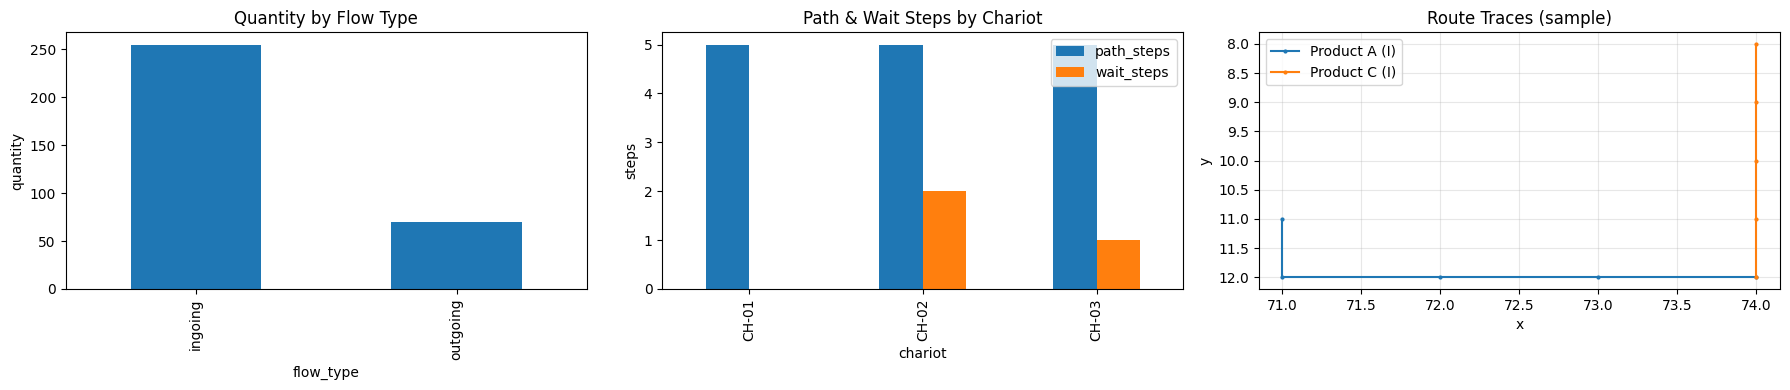

In [27]:
# --- Demo 1: Single incoming storage optimization (floors 1-4 only) ---

sample_product_id = str(
    df_products_raw.loc[
        df_products_raw["id_produit"].astype(str).str.match(r"^\d+$", na=False),
        "id_produit",
    ].iloc[0]
)
sample_weight = 42.0

result = coordinator.process_incoming_storage(
    product_id=sample_product_id,
    sku_weight=sample_weight,
    employee_id="EMP-01",
    start_coord=(8, 8),
)

print("Storage allocation status:", result["status"])
if result["status"] == "ok":
    slot = result["slot"]
    print("Assigned slot:", slot.code_emplacement, "| floor:", slot.floor, "| zone:", slot.zone)
    print("ABC class:", result["abc_class"])
    print("Path length:", len(result["path"]))
    print("First scheduled steps:", result["time_schedule"][:8])
    display(result["top_scores"].head(5))
else:
    print(result["message"] )

# --- Demo 2: Chariot capacity optimization (greedy knapsack) ---

chariot_agent = ChariotCapacityAgent(capacity_kg=320.0)
pick_items = [
    {"product_id": "31334", "weight": 80.0, "priority": 90.0},
    {"product_id": "31335", "weight": 120.0, "priority": 95.0},
    {"product_id": "31336", "weight": 50.0, "priority": 40.0},
    {"product_id": "31337", "weight": 130.0, "priority": 99.0},
    {"product_id": "31338", "weight": 70.0, "priority": 72.0},
]
selected, total_weight = chariot_agent.optimize_batch(pick_items)

print("\nChariot selection:")
print("Selected count:", len(selected), "| total weight:", total_weight)
print(pd.DataFrame(selected))

# --- Shared helpers: demand-driven item generation + Haithem-style Dijkstra shortest path ---

def _infer_weight_column(df: pd.DataFrame) -> Optional[str]:
    candidates = [c for c in df.columns if any(k in str(c).lower() for k in ["poids", "weight"])]
    return candidates[0] if candidates else None

def _build_incoming_items(
    products_df: pd.DataFrame,
    demand_df: pd.DataFrame,
    demand_agent: DemandFrequencyAgent,
    max_products: int = 20,
    max_qty_per_product: int = 18,
) -> List[Dict[str, float]]:
    if demand_df.empty or "id_produit" not in demand_df.columns or "quantite_demande" not in demand_df.columns:
        return []

    dd = demand_df.copy()
    dd["id_produit"] = dd["id_produit"].astype(str).str.strip()
    dd["quantite_demande"] = pd.to_numeric(dd["quantite_demande"], errors="coerce").fillna(0.0)

    grouped = dd.groupby("id_produit", as_index=False).agg(
        total_qty=("quantite_demande", "sum"),
        mean_qty=("quantite_demande", "mean"),
        demand_count=("quantite_demande", "size"),
    )
    grouped = grouped.sort_values("total_qty", ascending=False).head(max_products).reset_index(drop=True)

    p = products_df.copy()
    p["id_produit"] = p["id_produit"].astype(str).str.strip()

    weight_col = _infer_weight_column(p)
    if weight_col is None:
        p["_unit_weight"] = 8.0
    else:
        p["_unit_weight"] = pd.to_numeric(p[weight_col], errors="coerce").fillna(8.0).clip(lower=0.5, upper=45.0)

    unit_weight_map = p.set_index("id_produit")["_unit_weight"].to_dict()

    items: List[Dict[str, float]] = []
    for _, row in grouped.iterrows():
        pid = str(row["id_produit"] )
        qty = int(max(1, min(max_qty_per_product, round(float(row["mean_qty"])))) )
        unit_w = float(unit_weight_map.get(pid, 8.0))
        total_w = float(qty * unit_w)
        demand_priority = float(demand_agent.priority_value(pid))
        freq = float(demand_agent.frequency_by_product.get(pid, 0.0))

        items.append(
            {
                "product_id": pid,
                "quantity": qty,
                "unit_weight": unit_w,
                "weight": total_w,
                "priority": 100.0 * demand_priority + 10.0 * freq,
            }
        )

    return items

def _slot_bounds_by_floor(slots: List[WarehouseSlot]) -> Dict[int, Tuple[int, int, int, int]]:
    bounds: Dict[int, Tuple[int, int, int, int]] = {}
    for floor in [1, 2, 3, 4]:
        pts = [(s.x, s.y) for s in slots if s.floor == floor]
        if not pts:
            continue
        xs = [x for x, _ in pts]
        ys = [y for _, y in pts]
        bounds[floor] = (min(xs), max(xs), min(ys), max(ys))
    return bounds

def _clip_point_to_bounds(point_xy: Tuple[int, int], bounds: Tuple[int, int, int, int]) -> Tuple[int, int]:
    x, y = int(point_xy[0]), int(point_xy[1])
    xmin, xmax, ymin, ymax = bounds
    return (min(max(x, xmin), xmax), min(max(y, ymin), ymax))

def dijkstra_shortest_path_2d(
    start_xy: Tuple[int, int],
    goal_xy: Tuple[int, int],
    bounds: Tuple[int, int, int, int],
) -> Tuple[float, List[Tuple[int, int]]]:
    # Adapted from ai/haithem/Warehouse_Grid_Model_Explained.ipynb Dijkstra structure
    xmin, xmax, ymin, ymax = bounds

    def in_bounds(x: int, y: int) -> bool:
        return xmin <= x <= xmax and ymin <= y <= ymax

    start = _clip_point_to_bounds(start_xy, bounds)
    goal = _clip_point_to_bounds(goal_xy, bounds)
    if not in_bounds(*start) or not in_bounds(*goal):
        return float("inf"), []

    pq: List[Tuple[float, Tuple[int, int]]] = [(0.0, start)]
    dist = {start: 0.0}
    prev = {start: None}

    while pq:
        d, node = heappop(pq)
        if d != dist.get(node, float("inf")):
            continue
        if node == goal:
            break

        x, y = node
        for nxt in [(x + 1, y), (x - 1, y), (x, y + 1), (x, y - 1)]:
            if not in_bounds(*nxt):
                continue
            nd = d + 1.0
            if nd < dist.get(nxt, float("inf")):
                dist[nxt] = nd
                prev[nxt] = node
                heappush(pq, (nd, nxt))

    if goal not in dist:
        return float("inf"), []

    path: List[Tuple[int, int]] = []
    cur: Optional[Tuple[int, int]] = goal
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return dist[goal], path

def _path_or_manhattan(
    start_xy: Tuple[int, int],
    goal_xy: Tuple[int, int],
    floor_bounds: Optional[Tuple[int, int, int, int]],
) -> List[Tuple[int, int]]:
    if floor_bounds is None:
        return manhattan_path(start_xy, goal_xy)
    _, path = dijkstra_shortest_path_2d(start_xy, goal_xy, floor_bounds)
    if path:
        return path
    return manhattan_path(start_xy, goal_xy)

def _choose_best_pick_record(
    stock_records: List[Dict[str, object]],
    expedition_xy: Tuple[int, int],
    bounds_by_floor: Dict[int, Tuple[int, int, int, int]],
) -> Tuple[Optional[int], float, List[Tuple[int, int]]]:
    best_idx: Optional[int] = None
    best_cost = float("inf")
    best_path: List[Tuple[int, int]] = []

    for idx, rec in enumerate(stock_records):
        slot = rec["slot"]
        floor = int(slot.floor)
        floor_bounds = bounds_by_floor.get(floor)
        start_xy = (int(slot.x), int(slot.y))
        goal_xy = expedition_xy

        if floor_bounds is None:
            path = manhattan_path(start_xy, goal_xy)
            cost = float(len(path) - 1)
        else:
            cost, path = dijkstra_shortest_path_2d(start_xy, goal_xy, floor_bounds)
            if not path:
                path = manhattan_path(start_xy, goal_xy)
                cost = float(len(path) - 1)

        if cost < best_cost:
            best_cost = cost
            best_path = path
            best_idx = idx

    return best_idx, best_cost, best_path

# --- Demo 3: Full simulation (quantity -> chariot max capacity -> allocation -> shortest path) ---

incoming_items = _build_incoming_items(
    products_df=df_products_raw,
    demand_df=df_demand_raw,
    demand_agent=demand_agent,
    max_products=25,
    max_qty_per_product=16,
)

print("\nIncoming candidate count:", len(incoming_items))
if incoming_items:
    display(pd.DataFrame(incoming_items).head(10))

chariot_agent_full = ChariotCapacityAgent(capacity_kg=420.0)
selected_batch, selected_batch_weight = chariot_agent_full.optimize_batch(incoming_items)

print("\nChariot full-load optimization:")
print("Selected products:", len(selected_batch), "| total load kg:", round(selected_batch_weight, 2))
if selected_batch:
    display(pd.DataFrame(selected_batch).sort_values("priority", ascending=False).head(15))

bounds_by_floor = _slot_bounds_by_floor(slot_agent.slots)
alloc_rows: List[Dict[str, object]] = []

for idx, item in enumerate(selected_batch, start=1):
    pid = str(item["product_id"] )
    total_item_weight = float(item["weight"] )

    allocation = coordinator.process_incoming_storage(
        product_id=pid,
        sku_weight=total_item_weight,
        employee_id=f"EMP-{idx:02d}",
        start_coord=(8, 8),
    )

    if allocation.get("status") != "ok":
        alloc_rows.append(
            {
                "product_id": pid,
                "quantity": int(item["quantity"]),
                "total_weight": total_item_weight,
                "status": "error",
                "message": allocation.get("message", "Allocation failed"),
            }
        )
        continue

    slot = allocation["slot"]
    floor = int(slot.floor)
    floor_bounds = bounds_by_floor.get(floor)
    dock_xy = dock_by_floor.get(floor, (8, 8))
    path_nodes = _path_or_manhattan(dock_xy, (int(slot.x), int(slot.y)), floor_bounds)
    path_cost = float(max(0, len(path_nodes) - 1))

    alloc_rows.append(
        {
            "product_id": pid,
            "quantity": int(item["quantity"]),
            "total_weight": round(total_item_weight, 2),
            "priority": round(float(item["priority"]), 4),
            "abc_class": allocation["abc_class"],
            "assigned_slot": slot.code_emplacement,
            "floor": floor,
            "zone": slot.zone,
            "shortest_path_cost": path_cost,
            "shortest_path_steps": len(path_nodes),
            "path_preview": path_nodes[:6],
            "status": "ok",
        }
    )

print("\nIntegrated simulation result (chariot + allocation + shortest path):")
if alloc_rows:
    sim_df = pd.DataFrame(alloc_rows)
    display(sim_df)
    print("Allocated successfully:", int((sim_df["status"] == "ok").sum()), "/", len(sim_df))
else:
    print("No simulation rows were generated.")

# --- Demo 4: Warehouse Operations Simulation (improved allocation/picking + movement collisions) ---

import matplotlib.pyplot as plt

chariot_count = 3
chariot_capacity_kg = 320.0
expedition_zone = (110, 10)

print("\nAssumptions:")
print("- Floors limited to 1..4")
print("- Collisions are between chariot movements in (x,y,t), independent of flow type")
print("- Picking selects best stock location by shortest path to expedition")

op_sequence = pd.DataFrame(
    [
        {"date": "2026-01-01", "product": "Product A", "flow_type": "ingoing", "quantity": 120, "weight_kg": 2.0},
        {"date": "2026-01-02", "product": "Product B", "flow_type": "outgoing", "quantity": 40, "weight_kg": 2.5},
        {"date": "2026-01-03", "product": "Product C", "flow_type": "ingoing", "quantity": 75, "weight_kg": 1.8},
        {"date": "2026-01-04", "product": "Product D", "flow_type": "outgoing", "quantity": 30, "weight_kg": 3.0},
        {"date": "2026-01-05", "product": "Product E", "flow_type": "ingoing", "quantity": 60, "weight_kg": 2.2},
    ]
)
op_sequence["date"] = pd.to_datetime(op_sequence["date"] )
op_sequence = op_sequence.sort_values("date").reset_index(drop=True)

chariot_pool = [f"CH-{i+1:02d}" for i in range(chariot_count)]
chariot_available_t = {cid: 0 for cid in chariot_pool}

inventory_map: Dict[str, List[Dict[str, object]]] = {}
operations_output: List[Dict[str, object]] = []
bounds_by_floor = _slot_bounds_by_floor(slot_agent.slots)

# Movement collisions are evaluated only by this dedicated movement agent
movement_collision_agent = ReservationTableCollisionAgent()

for i, row in op_sequence.iterrows():
    chariot_id = chariot_pool[i % len(chariot_pool)]
    product = str(row["product"] )
    flow_type = str(row["flow_type"]).lower().strip()
    quantity = int(row["quantity"] )
    unit_weight = float(row["weight_kg"] )

    batch_weight = quantity * unit_weight
    trips_required = int(math.ceil(batch_weight / chariot_capacity_kg))
    per_trip_qty = int(math.ceil(quantity / trips_required)) if trips_required > 0 else quantity

    for trip_idx in range(trips_required):
        trip_qty = min(per_trip_qty, quantity - trip_idx * per_trip_qty)
        if trip_qty <= 0:
            continue

        trip_weight = float(trip_qty * unit_weight)
        employee_id = f"{chariot_id}-T{trip_idx+1}"
        start_t = chariot_available_t[chariot_id]

        if flow_type == "ingoing":
            allocation = coordinator.process_incoming_storage(
                product_id=product,
                sku_weight=trip_weight,
                employee_id=employee_id,
                start_coord=(8, 8),
            )

            if allocation.get("status") == "ok":
                slot = allocation["slot"]
                floor = int(slot.floor)
                floor_bounds = bounds_by_floor.get(floor)
                start_xy = dock_by_floor.get(floor, (8, 8))
                goal_xy = (int(slot.x), int(slot.y))
                path = _path_or_manhattan(start_xy, goal_xy, floor_bounds)

                schedule = movement_collision_agent.reserve_path(employee_id, path, start_t=start_t)
                wait_steps = sum(1 for k in range(1, len(schedule)) if schedule[k][:2] == schedule[k - 1][:2])
                chariot_available_t[chariot_id] = (schedule[-1][2] + 1) if schedule else (start_t + len(path))

                inventory_map.setdefault(product, []).append(
                    {
                        "slot": slot,
                        "quantity": trip_qty,
                    }
                )

                operations_output.append(
                    {
                        "date": row["date"].date().isoformat(),
                        "chariot": chariot_id,
                        "product": product,
                        "flow_type": "ingoing",
                        "quantity": trip_qty,
                        "assigned_location": slot.code_emplacement,
                        "route": f"Receipt Zone -> Floor {slot.floor} / {slot.zone} -> {slot.code_emplacement}",
                        "path_steps": len(path),
                        "wait_steps": wait_steps,
                        "route_nodes": path[:30],
                        "start_t": start_t,
                        "end_t": chariot_available_t[chariot_id],
                        "justification": "Policy-aware allocation + shortest-path routing + movement collision deconfliction.",
                    }
                )
            else:
                operations_output.append(
                    {
                        "date": row["date"].date().isoformat(),
                        "chariot": chariot_id,
                        "product": product,
                        "flow_type": "ingoing",
                        "quantity": trip_qty,
                        "assigned_location": None,
                        "route": "No route",
                        "path_steps": 0,
                        "wait_steps": 0,
                        "route_nodes": [],
                        "start_t": start_t,
                        "end_t": start_t,
                        "justification": allocation.get("message", "No feasible slot under constraints."),
                    }
                )

        elif flow_type == "outgoing":
            stock = inventory_map.get(product, [])
            if not stock:
                operations_output.append(
                    {
                        "date": row["date"].date().isoformat(),
                        "chariot": chariot_id,
                        "product": product,
                        "flow_type": "outgoing",
                        "quantity": trip_qty,
                        "assigned_location": None,
                        "route": "No route",
                        "path_steps": 0,
                        "wait_steps": 0,
                        "route_nodes": [],
                        "start_t": start_t,
                        "end_t": start_t,
                        "justification": "No simulated stock available for requested outgoing product.",
                    }
                )
                continue

            best_idx, pick_cost, path = _choose_best_pick_record(
                stock_records=stock,
                expedition_xy=expedition_zone,
                bounds_by_floor=bounds_by_floor,
            )

            if best_idx is None:
                operations_output.append(
                    {
                        "date": row["date"].date().isoformat(),
                        "chariot": chariot_id,
                        "product": product,
                        "flow_type": "outgoing",
                        "quantity": trip_qty,
                        "assigned_location": None,
                        "route": "No route",
                        "path_steps": 0,
                        "wait_steps": 0,
                        "route_nodes": [],
                        "start_t": start_t,
                        "end_t": start_t,
                        "justification": "No reachable stock slot found.",
                    }
                )
                continue

            picked = stock[best_idx]
            slot = picked["slot"]
            picked["quantity"] = max(0, int(picked["quantity"]) - trip_qty)
            if picked["quantity"] == 0:
                stock.pop(best_idx)

            schedule = movement_collision_agent.reserve_path(employee_id, path, start_t=start_t)
            wait_steps = sum(1 for k in range(1, len(schedule)) if schedule[k][:2] == schedule[k - 1][:2])
            chariot_available_t[chariot_id] = (schedule[-1][2] + 1) if schedule else (start_t + len(path))

            operations_output.append(
                {
                    "date": row["date"].date().isoformat(),
                    "chariot": chariot_id,
                    "product": product,
                    "flow_type": "outgoing",
                    "quantity": trip_qty,
                    "assigned_location": slot.code_emplacement,
                    "route": f"{slot.code_emplacement} -> Expedition Zone",
                    "path_steps": len(path),
                    "wait_steps": wait_steps,
                    "route_nodes": path[:30],
                    "start_t": start_t,
                    "end_t": chariot_available_t[chariot_id],
                    "justification": f"Best-pick slot by shortest path (cost={pick_cost:.1f}) + movement collision deconfliction.",
                }
            )

ops_df = pd.DataFrame(operations_output)
print("\nWarehouse Operations Simulation output:")
display(ops_df[[
    "date",
    "chariot",
    "product",
    "flow_type",
    "quantity",
    "assigned_location",
    "route",
    "path_steps",
    "wait_steps",
    "start_t",
    "end_t",
    "justification",
]])

print("\nOperational resources used:")
print("- chariots:", chariot_count)
print("- chariot_capacity_kg:", chariot_capacity_kg)
print("- active instructions:", len(ops_df))
print("- total_wait_steps_due_to_movement_collisions:", int(ops_df["wait_steps"].sum()) if not ops_df.empty else 0)

print("\nOutput format preview (explicit operational instructions):")
for _, r in ops_df.head(8).iterrows():
    loc = r["assigned_location"] if pd.notna(r["assigned_location"]) else "N/A"
    print(f"- {r['product']}: {r['flow_type'].title()} -> {loc} | Route: {r['route']}")

# --- Visualization ---
if not ops_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ops_df.groupby("flow_type")["quantity"].sum().plot(kind="bar", ax=axes[0], title="Quantity by Flow Type")
    axes[0].set_xlabel("flow_type")
    axes[0].set_ylabel("quantity")

    ops_df.groupby("chariot")[["path_steps", "wait_steps"]].sum().plot(kind="bar", ax=axes[1], title="Path & Wait Steps by Chariot")
    axes[1].set_xlabel("chariot")
    axes[1].set_ylabel("steps")

    for _, rr in ops_df.head(4).iterrows():
        nodes = rr["route_nodes"]
        if isinstance(nodes, list) and len(nodes) > 0:
            xs = [p[0] for p in nodes]
            ys = [p[1] for p in nodes]
            axes[2].plot(xs, ys, marker="o", linewidth=1.5, markersize=2, label=f"{rr['product']} ({rr['flow_type'][0].upper()})")
    axes[2].invert_yaxis()
    axes[2].set_title("Route Traces (sample)")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    axes[2].legend(loc="best")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()